# Fuel the Data _ Data Merge

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [17]:
os.chdir("/Users/soobin/Documents/fuelthedata")

poverty = pd.read_excel("data/PovertyReport.xlsx", skiprows=5)
unemployment = pd.read_excel("data/UnemploymentReport.xlsx", skiprows=3)
crime = pd.read_excel(
    "data/offenses-known-to-le-2024/CIUS_Table_8_Offenses_Known_to_Law_Enforcement_by_State_by_City_2024.xlsx",
    skiprows=3)

In [18]:
print(crime.head())
print(crime.columns)

     State         City  Population  Violent\ncrime  \
0  ALABAMA    Abbeville      2386.0            11.0   
1  ALABAMA   Adamsville      4111.0            23.0   
2  ALABAMA      Addison       669.0             3.0   
3  ALABAMA    Alabaster     34349.0            34.0   
4  ALABAMA  Albertville     23242.0            55.0   

   Murder and\nnonnegligent\nmanslaughter  Rape  Robbery  Aggravated\nassault  \
0                                     0.0   2.0      1.0                  8.0   
1                                     1.0   1.0      0.0                 21.0   
2                                     0.0   0.0      0.0                  3.0   
3                                     0.0   1.0      4.0                 29.0   
4                                     1.0  14.0      3.0                 37.0   

   Property\ncrime  Burglary  Larceny-\ntheft  Motor\nvehicle\ntheft  Arson1  
0             35.0       9.0             25.0                    1.0     0.0  
1            130.0      

In [19]:
print(unemployment.head())
print(unemployment.columns)

  Unnamed: 0   FIPS         Name  2015  2016  2017  2018  2019  2020  2021  \
0        NaN  1000.0     Alabama   6.1   5.9   4.5   3.9   3.2   6.4   3.4   
1        NaN  2000.0      Alaska   6.3   6.6   6.5   6.0   5.6   8.3   6.4   
2        NaN  4000.0     Arizona   6.1   5.5   5.0   4.8   4.8   7.8   5.1   
3        NaN  5000.0    Arkansas   5.0   4.0   3.7   3.7   3.5   6.2   4.0   
4        NaN  6000.0  California   6.3   5.5   4.8   4.2   4.1  10.1   7.3   

   2022  2023 Median Household Income (2022)  
0   2.5   2.5                        $59,703  
1   4.2   4.2                        $88,072  
2   3.8   3.9                        $74,355  
3   3.2   3.3                        $55,505  
4   4.3   4.8                        $91,517  
Index([                    'Unnamed: 0',                          'FIPS ',
                                 'Name',                           '2015',
                                   2016,                             2017,
                        

In [20]:
print(poverty.head())
print(poverty.columns)

         Name  Unnamed: 1  Unnamed: 2  Unnamed: 3  Percent  Unnamed: 5  \
0     Alabama         NaN         NaN         NaN     15.7         NaN   
1      Alaska         NaN         NaN         NaN     10.5         NaN   
2     Arizona         NaN         NaN         NaN     12.6         NaN   
3    Arkansas         NaN         NaN         NaN     15.4         NaN   
4  California         NaN         NaN         NaN     12.0         NaN   

   Lower Bound  Upper Bound  Percent.1  Lower Bound.1  Upper Bound.1  
0         15.3         16.1       21.3           20.5           22.1  
1          9.9         11.1       12.5           11.4           13.6  
2         12.3         12.9       15.8           15.1           16.5  
3         15.0         15.8       20.2           19.1           21.3  
4         11.9         12.1       15.0           14.6           15.4  
Index(['Name', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Percent',
       'Unnamed: 5', 'Lower Bound', 'Upper Bound', 'Percent.1

In [21]:
poverty = poverty[['Name', 'Percent']]
poverty = poverty.rename(columns={
    'Name': 'State',
    'Percent': 'Poverty Rate'
})

In [22]:
unemployment = unemployment[['Name', '2023']]
unemployment = unemployment.rename(columns={
    'Name': 'State',
    '2023': 'Unemployment Rate'
})

In [23]:
crime.columns = crime.columns.str.replace('\n', ' ')
crime = crime[['State', 'Violent crime']]
crime_state = crime.groupby('State')['Violent crime'].sum().reset_index()
crime_state['State'] = crime_state['State'].str.title()

In [27]:
print(poverty.head())
print(unemployment.head())

        State  Poverty Rate
0     Alabama          15.7
1      Alaska          10.5
2     Arizona          12.6
3    Arkansas          15.4
4  California          12.0
        State  Unemployment Rate
0     Alabama                2.5
1      Alaska                4.2
2     Arizona                3.9
3    Arkansas                3.3
4  California                4.8


In [24]:
merged = poverty.merge(unemployment, on="State")

In [26]:
merged = merged.merge(crime_state, on='State')

In [27]:
print(merged.head())
print(merged.shape)

        State  Poverty Rate  Unemployment Rate  Violent crime
0     Alabama          15.7                2.5        14287.0
1      Alaska          10.5                4.2         3705.0
2     Arizona          12.6                3.9        27341.0
3    Arkansas          15.4                3.3        13509.0
4  California          12.0                4.8       155986.0
(48, 4)


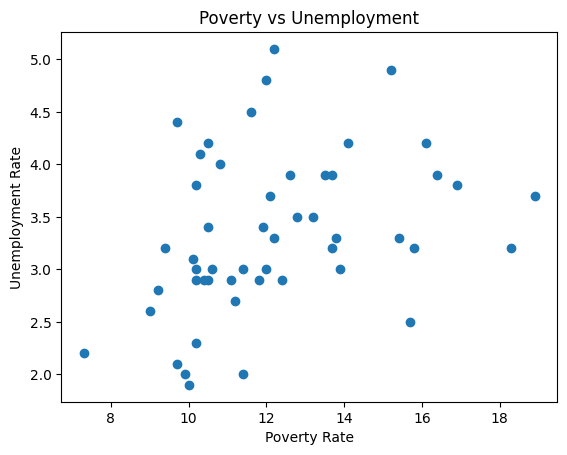

In [30]:
plt.scatter(merged['Poverty Rate'], merged['Unemployment Rate'])
plt.xlabel('Poverty Rate')
plt.ylabel('Unemployment Rate')
plt.title('Poverty vs Unemployment')
plt.show()

The scatter plot shows the relationship between poverty rate and unemployment rate across states. Overall, there does not appear to be a strong linear relationship between the two variables. While some states with higher poverty rates also have higher unemployment, the data points are widely scattered. This suggests that poverty and unemployment are not strongly correlated in this dataset.

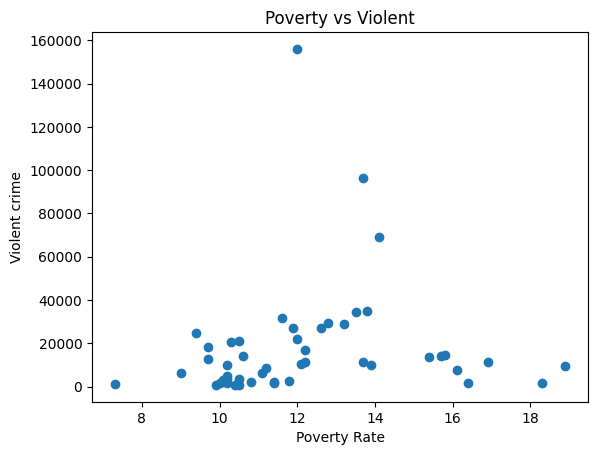

In [33]:
plt.scatter(merged['Poverty Rate'], merged['Violent crime'])
plt.xlabel('Poverty Rate')
plt.ylabel('Violent crime')
plt.title('Poverty vs Violent')
plt.show()

The scatter plot shows the relationship between poverty rate and violent crime across states. Overall, there appears to be a slight positive relationship, where states with higher poverty rates tend to have higher levels of violent crime. However, the data points are widely dispersed, indicating that the relationship is not very strong. In addition, a few states exhibit extremely high levels of violent crime compared to others, suggesting the presence of outliers. These outliers may influence the overall pattern and indicate that factors other than poverty also play a significant role in determining crime rates.

In [32]:
corr = merged.corr(numeric_only=True)
print(corr)

                   Poverty Rate  Unemployment Rate  Violent crime
Poverty Rate           1.000000           0.304713       0.114839
Unemployment Rate      0.304713           1.000000       0.463326
Violent crime          0.114839           0.463326       1.000000


The correlation analysis shows different levels of relationships among the variables. The correlation between poverty rate and unemployment rate is approximately 0.30, indicating a weak positive relationship. 

The relationship between poverty rate and violent crime is much weaker, with a correlation of about 0.11, suggesting little to no linear association between these two variables. 

In contrast, unemployment rate shows a moderate positive correlation with violent crime (approximately 0.46), indicating that higher unemployment may be more closely associated with increased levels of violent crime compared to poverty. Overall, these results suggest that unemployment may be a more important factor than poverty in explaining variations in violent crime across states.